### InsightFace Smoke Test

Goal: understand what InsightFace returns before building the modular face filter stage.

This smoke test validates:

1. Whether the model loads correctly with CUDA or CPU provider
2. Cold-start vs warm inference timing
3. Attributes available on each detected `Face` object
4. Ordering of the 5 facial landmarks (`kps`)
5. Whether outputs are pixel-space or normalized coordinates


### Notebook config and imports 

In [1]:
from __future__ import annotations 

import time 
from pathlib import Path 

import cv2 
import numpy as np 

from src.constants import IMAGES_DIR
from src.logger.custom_logger import configure_logger,logger 
from src.utils.io import ImageLoader 
from insightface.app import FaceAnalysis


15:40:38 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-10\15-40-38.log


In [2]:
configure_logger(log_level="INFO")

15:40:47 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-10\15-40-47.log


WindowsPath('C:/Users/rsurs/OneDrive/Documents/cynapse-ai-assignment/logs/2026-05-10/15-40-47.log')

In [3]:
loader = ImageLoader()

In [4]:
t0 = time.perf_counter()

app = FaceAnalysis(name="buffalo_l",
                   allowed_modules=['detection'], # allowed_modules tells InsightFace which parts of model pipeline to load
                   providers=["CUDAExecutionProvider", "CPUExecutionProvider"])

app.prepare(ctx_id=0,det_size=(640,640)) # ctx_id tells InsightFace to run on GPU/CPU
# prepare loads the weights and sets input size 
load_ms = (time.perf_counter() - t0) * 1000 
print(f"Loaded InsightFace model in {load_ms:.0f}ms") 

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
model ignore: C:\Users\rsurs/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecu

### Inspect output structure of InsightFace

In [5]:
sample_path  = IMAGES_DIR / "crop (33).png"
crop = loader.load(sample_path)
print(f"Loaded image {crop.crop_id}, shape: {crop.image.shape}")

img_bgr = cv2.cvtColor(crop.image,cv2.COLOR_RGB2BGR)

# cold inference
t0 = time.perf_counter()
faces = app.get(img_bgr)
cold_ms = (time.perf_counter() - t0) * 1000 

# warm inference
t0 = time.perf_counter()
faces = app.get(img_bgr)
warm_ms = (time.perf_counter() - t0) * 1000 


print(f"cold inference time: {cold_ms:.0f}")
print(f"warm inference time: {warm_ms:.0f}")
print(f"No of faces detected: {len(faces)}")
print("type of result: ",type(faces))

if faces:
    print(f"type of one face: ",type(faces[0]))

15:40:49 | INFO     | src.utils.io:load:61 | Loaded crop (33).png | shape: ((163, 600, 3)) | bytes: 293400
Loaded image crop (33), shape: (600, 163, 3)
cold inference time: 307
warm inference time: 13
No of faces detected: 1
type of result:  <class 'list'>
type of one face:  <class 'insightface.app.common.Face'>


In [6]:
faces

[{'bbox': array([114.49842 ,  16.544392, 154.10854 ,  79.99805 ], dtype=float32),
  'kps': array([[139.08041 ,  41.397396],
         [147.08063 ,  40.60189 ],
         [152.96062 ,  52.61599 ],
         [141.75006 ,  65.039116],
         [147.58784 ,  64.826744]], dtype=float32),
  'det_score': np.float32(0.7912696)}]

### Inspecting the InsightFace output attributes

In [7]:
face = faces[0]
print("Examining attributes on Face object")
for attr in dir(face):
    if attr.startswith("_"):
        continue
    
    try:
        value = getattr(face,attr) 
        
        if callable(value): 
            # can the object be called as a function 
            continue

        shape = getattr(value,"shape",None)
        print(f"  {attr:<15}  type={type(value).__name__}  "
                  f"shape={shape if shape is not None else 'N/A'}")
    except Exception as exc:
        print(f"  {attr}: <error: {exc}>")

Examining attributes on Face object
  bbox             type=ndarray  shape=(4,)
  det_score        type=float32  shape=()
  embedding_norm   type=NoneType  shape=N/A
  kps              type=ndarray  shape=(5, 2)
  normed_embedding  type=NoneType  shape=N/A
  sex              type=NoneType  shape=N/A


1. `bbox`: Indicates where face is in the image ?. Contains 4 coordinates `[x1,y1,x2,y2]`.

2. `det_score`: This tells how confident detector identifies the face ?. ex, 0.98

3. `kps`: This means keypoints which denote important facial landmark coordinates. Consists of 5 points:
    - left eye 
    - right eye 
    - nose 
    - left mouth corner 
    - right mouth corner 

4. `embedding`: Most important recognition feature. A numeric representation vector of face. Usually `shape=(512,)`. 
    - If we have faces of same person embeddings are closer. 
    - If we have different faces embeddings are far apart.

5. `normed_embedding`: Embedding after normalization. Vector length adds upto 1.

6. `sex`: Predicted sex from face. 0 maps to female and 1 maps to male.

### Examing the output

In [8]:
face = faces[0]
print(f"bbox (pixels): {face.bbox}")
print(f"x1={face.bbox[0]:.1f}, y1={face.bbox[1]:.1f}")
print(f"x2={face.bbox[2]:.1f}, y2={face.bbox[3]:.1f}\n")
print(f"width={face.bbox[2] - face.bbox[0]:.1f}, height={face.bbox[3] - face.bbox[1]:.1f}\n")
print(f"Detection confidence:{face.det_score:.3f}")


print(f"\nKeypoints (kps), shape {face.kps.shape}:")
print(f"  [right_eye]    {face.kps[0]}")
print(f"  [left_eye]     {face.kps[1]}")
print(f"  [nose]         {face.kps[2]}")
print(f"  [right_mouth]  {face.kps[3]}")
print(f"  [left_mouth]   {face.kps[4]}")

print(f"\nCrop dimensions for sanity-check: H={crop.height}, W={crop.width}")


bbox (pixels): [114.49842   16.544392 154.10854   79.99805 ]
x1=114.5, y1=16.5
x2=154.1, y2=80.0

width=39.6, height=63.5

Detection confidence:0.791

Keypoints (kps), shape (5, 2):
  [right_eye]    [139.08041   41.397396]
  [left_eye]     [147.08063  40.60189]
  [nose]         [152.96062  52.61599]
  [right_mouth]  [141.75006   65.039116]
  [left_mouth]   [147.58784   64.826744]

Crop dimensions for sanity-check: H=600, W=163


### Visualizing the landmarks and bbox 

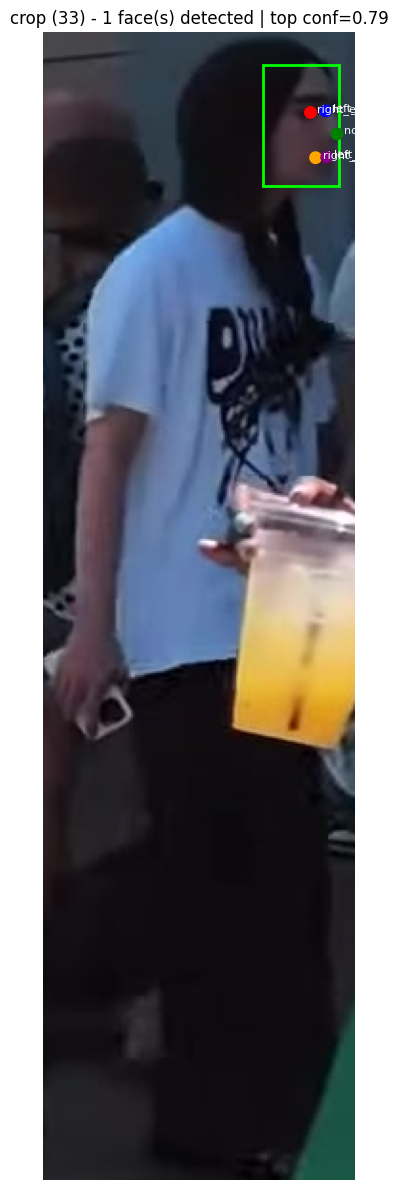

In [9]:
import matplotlib.pyplot as plt 
from matplotlib.patches import Circle,Rectangle
from src.constants import LANDMARK_NAMES,COLORS

fig,ax = plt.subplots(figsize=(8,12))
ax.imshow(crop.image)

for face in faces:
    x1,y1,x2,y2 = face.bbox 
    ax.add_patch(Rectangle((x1,y1),
                           x2 - x1,
                           y2 - y1,
                           fill=False,
                           edgecolor="lime",
                           linewidth=2))
    
    for i,((x,y),name,color) in enumerate(zip(face.kps,LANDMARK_NAMES,COLORS)):
        ax.add_patch(Circle((x,y),radius=3,color=color))
        ax.annotate(name,(x,y),fontsize=8,color="white",xytext=(5,0),textcoords="offset points")

ax.set_title(f"{crop.crop_id} - {len(faces)} face(s) detected | "
             f"top conf={faces[0].det_score:.2f}"
)
ax.axis("off")
plt.tight_layout()
plt.show()


### Stage 3 Diagnostic — Investigating the 22% Face Rejection on Pose-Survivors

Stage 3 rejects 99 of 458 crops that already passed Stage 2. Two hypotheses:

- **H1 — back-of-head views.** Stage 2 detects head keypoints (which include ears) so it accepts backs of heads; Stage 3's SCRFD requires a face. Stage 3 is doing complementary filtering.
- **H2 — Stage 3 thresholds too strict.** `min_face_area_ratio = 0.005` or `min_detection_confidence = 0.6` may be cutting borderline-acceptable faces.

Eyeball + sensitivity sweep tells us which.

In [10]:
from __future__ import annotations

from pathlib import Path
import hashlib

import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 

from src.components.face_filter import FaceFilter
from src.components.person_detector import PersonDetector
from src.components.pose_filter import PoseFilter
from src.components.quality_filter import QualityFilter 
from src.constants import IMAGES_DIR

from src.settings.config import (FaceThresholds,
                                 PersonDetectionThresholds,
                                 PoseThresholds,
                                 QualityThresholds)

from src.utils.io import ImageLoader 

In [11]:
configure_logger(log_level="WARNING")

WindowsPath('C:/Users/rsurs/OneDrive/Documents/cynapse-ai-assignment/logs/2026-05-10/15-40-52.log')

In [12]:
quality_filter = QualityFilter(QualityThresholds())
detector = PersonDetector(PersonDetectionThresholds())
pose = PoseFilter(PoseThresholds())
face_filter = FaceFilter(FaceThresholds())
loader = ImageLoader()

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
model ignore: C:\Users\rsurs/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecu

In [13]:
def file_hash(path: Path) -> str:
    return hashlib.md5(path.read_bytes()).hexdigest()

all_paths = sorted(IMAGES_DIR.glob("*.png"))
seen: set[str] = set()
unique_paths: list[Path] = []

for p in all_paths:
    h = file_hash(p)

    if h in seen:
        continue
    
    seen.add(h)
    unique_paths.append(p)

records: list[dict] = []
for path in unique_paths:
    crop = loader.load(path)
    rec = {"crop_id":crop.crop_id,"source_path":str(path)}

    if not quality_filter.apply(crop).passed:
        rec['stage_reached'] = "quality"
        records.append(rec)
        continue 

    if not detector.apply(crop).passed:
        rec['stage_reached'] = "detection"
        records.append(rec)
        continue 

    if not pose.apply(crop).passed:
        rec['stage_reached'] = "pose"
        records.append(rec)
        continue
    
    face_result = face_filter.apply(crop)
    rec['stage_reached'] = "face"
    rec['passed_face'] = face_result.passed
    rec['face_reason'] = face_result.reason
    rec['n_faces'] = face_result.metrics.get("n_faces")
    rec["top_face_confidence"] = face_result.metrics.get("top_face_confidence")
    rec["top_face_area_ratio"] = face_result.metrics.get("top_face_area_ratio")
    rec["all_landmarks_in_bbox"] = face_result.metrics.get("all_landmarks_in_bbox")
    records.append(rec)

df = pd.DataFrame.from_records(records)
print(f"Total: {len(df)}")
print(df["stage_reached"].value_counts())


Total: 1001
stage_reached
detection    323
pose         253
quality      217
face         208
Name: count, dtype: int64


### Examining the rejected images by InsightFace

In [16]:
face_evaluated = df[df['stage_reached'] == 'face'].copy()
print(f"Number of images that reached till face detection stage: {len(face_evaluated)}")

num_images_passed = (face_evaluated["passed_face"] == True).sum()
num_images_failed = (face_evaluated["passed_face"] == False).sum() 
print(f"Number of images that passed the face detection: {num_images_passed}")
print(f"Number of images that failed the face detection: {num_images_failed}")

failed_reasons = face_evaluated[face_evaluated["passed_face"] == False]["face_reason"].value_counts()
print("\nFailure reasons\n")
print(failed_reasons)

Number of images that reached till face detection stage: 208
Number of images that passed the face detection: 124
Number of images that failed the face detection: 84

Failure reasons

face_reason
no_face_detected                                     73
face_conf=0.58<0.6                                    2
landmarks_outside_bbox                                2
face_conf=0.55<0.6                                    1
face_conf=0.52<0.6                                    1
face_conf=0.53<0.6                                    1
face_conf=0.54<0.6                                    1
face_conf=0.56<0.6                                    1
face_area_ratio=0.0005<0.005                          1
face_conf=0.53<0.6 | face_area_ratio=0.0028<0.005     1
Name: count, dtype: int64


### Visualizing the failed examples 

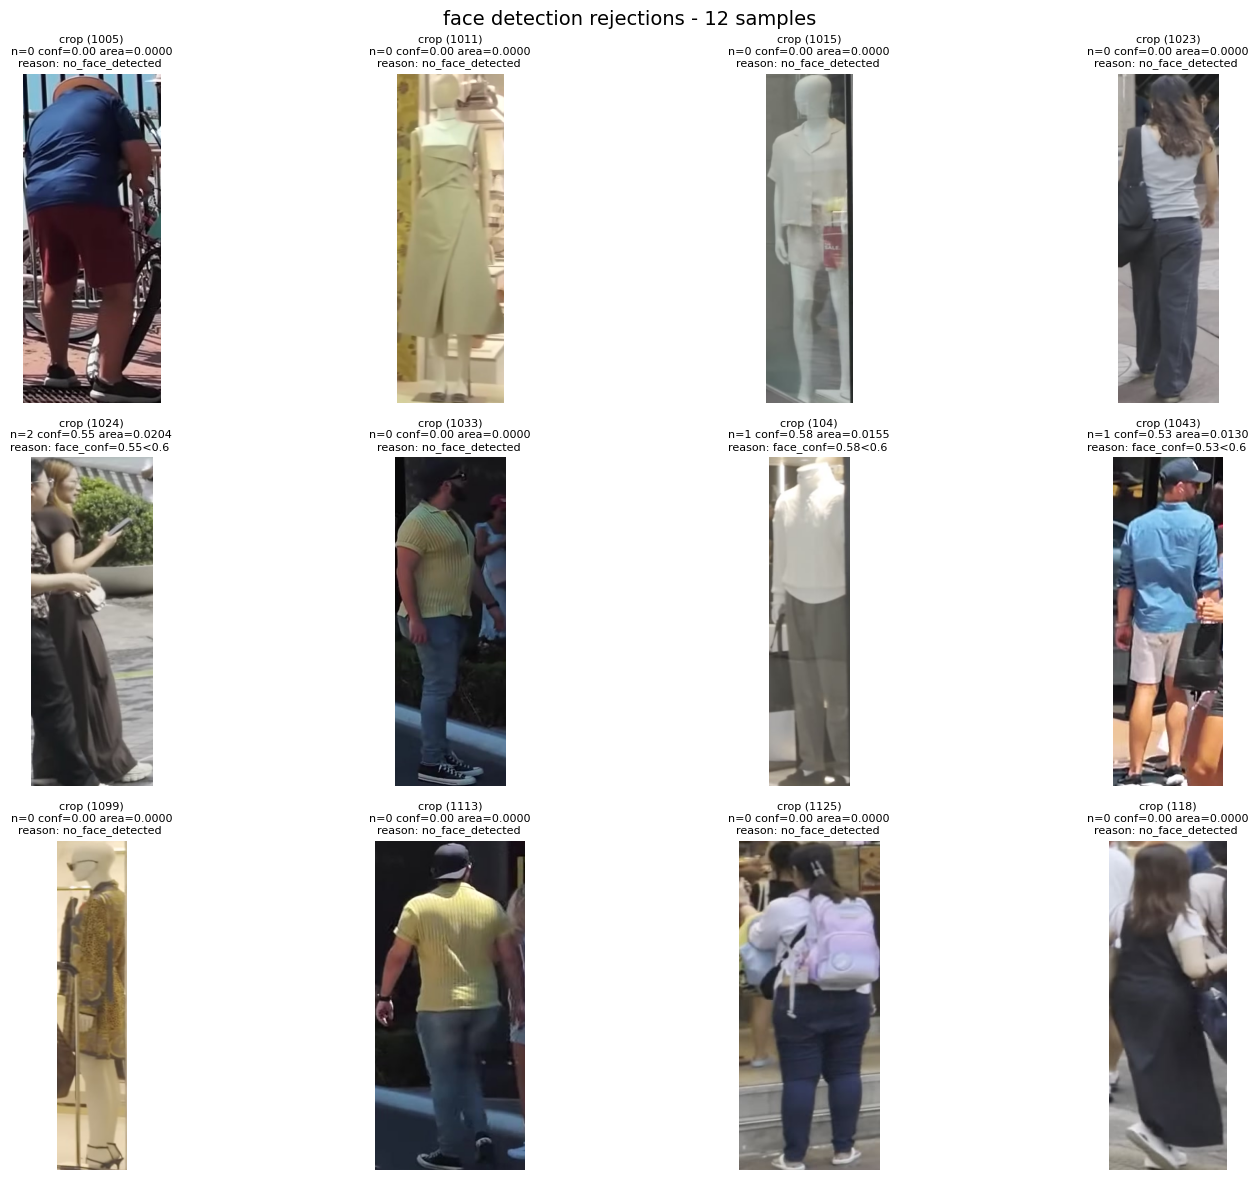

In [18]:
def show_grid(crops_df: pd.DataFrame,
              title: str,
              n: int = 12) -> None:
    
    sample = crops_df.head(n)
    
    n_rows = (len(sample) + 3) // 4
    n_cols = 4
    
    fig,axes = plt.subplots(n_rows,n_cols,figsize=(16,4 * n_rows))
    axes = np.atleast_2d(axes).flatten()

    for ax,(_,row) in zip(axes,sample.iterrows()):
        crop = loader.load(Path(row["source_path"]))
        ax.imshow(crop.image)
        ax.set_title(f"{row["crop_id"][:18]}\n"
                     f"n={int(row["n_faces"])} "
                     f"conf={row["top_face_confidence"]:.2f} "
                     f"area={row["top_face_area_ratio"]:.4f}\n"
                     f"reason: {row["face_reason"][:30]} ",
                     fontsize=8)
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    fig.suptitle(title,fontsize=14)
    plt.tight_layout()
    plt.show()

rejected = face_evaluated[face_evaluated["passed_face"] == False]
show_grid(rejected,"face detection rejections - 12 samples") 

### Rejection samples:
- Consists of Back of head views (back view of the person).
- Some side view of face and body images are detected.
- Manequin images 
 

### Sensitivity sweep

In [19]:
print("Sensitivity sweep on min_face_area_ratio (current=0.005)")
print(f"{'threshold':>14}  {'pass':>6}  {'rate':>6}")

for thresh in [0.001,0.003,0.005,0.01,0.02,0.05]:
    conf_ok = face_evaluated["top_face_confidence"] >= 0.6
    area_ok = face_evaluated["top_face_area_ratio"] >= thresh
    landmarks_ok = face_evaluated["all_landmarks_in_bbox"] == 1.0 
    n_pass = (conf_ok & area_ok & landmarks_ok).sum()
    print(f"{thresh:>14.3f}  {n_pass:>6}  {n_pass/len(face_evaluated)*100:>5.1f}%")

print()
print("Sensitivity sweep on min_detection_confidence (current = 0.6):")
print(f"{'threshold':>14}  {'pass':>6}  {'rate':>6}")
for thresh in [0.4, 0.5, 0.6, 0.7, 0.8]:
    conf_ok = face_evaluated["top_face_confidence"] >= thresh
    area_ok = face_evaluated["top_face_area_ratio"] >= 0.005
    landmarks_ok = face_evaluated["all_landmarks_in_bbox"] == 1.0
    n_pass = (conf_ok & area_ok & landmarks_ok).sum()
    print(f"{thresh:>14.2f}  {n_pass:>6}  {n_pass/len(face_evaluated)*100:>5.1f}%")


Sensitivity sweep on min_face_area_ratio (current=0.005)
     threshold    pass    rate
         0.001     124   59.6%
         0.003     124   59.6%
         0.005     124   59.6%
         0.010     120   57.7%
         0.020     114   54.8%
         0.050       0    0.0%

Sensitivity sweep on min_detection_confidence (current = 0.6):
     threshold    pass    rate
          0.40     131   63.0%
          0.50     131   63.0%
          0.60     124   59.6%
          0.70     113   54.3%
          0.80      86   41.3%


### Conclusion: Stage 3 is doing complementary filtering

- The evidence supports **H1 more than H2**. Most rejected crops fail because SCRFD finds **no face at all**, which matches back-of-head, hidden-face, mannequin, or non-frontal views that can still pass the pose stage.

- The thresholds do not look overly strict. Lowering `min_face_area_ratio` from `0.005` to `0.001` does not increase the pass count, and lowering confidence from `0.6` to `0.5` only adds a small number of crops.

- So Stage 3 should be kept as-is: pose confirms a body is visible, while SCRFD confirms an actual visible face. The final evaluation also supports this, with `face_hidden` reaching **90.62% coverage**.
